In [1]:
import pandas as pd
text = ['This is the NLP LECTURE written by prof Amin** ','IN this lecture I”ll be explaining various DATA-CLEANING techniques',
 'So stay tuned for FURther More &&','Nah I don"t think he goes to usf, he lives around']
df = pd.DataFrame({'text':text})


In [2]:
df

,text
0,This is the NLP LECTURE written by prof Amin**
1,IN this lecture I”ll be explaining various DAT...
2,So stay tuned for FURther More &&
3,"Nah I don""t think he goes to usf, he lives around"


In [3]:
df['lower'] = df['text'].apply(lambda x: " ".join(x.lower()  for x in x.split()))

In [4]:
df

,text,lower
0,This is the NLP LECTURE written by prof Amin**,this is the nlp lecture written by prof amin**
1,IN this lecture I”ll be explaining various DAT...,in this lecture i”ll be explaining various dat...
2,So stay tuned for FURther More &&,so stay tuned for further more &&
3,"Nah I don""t think he goes to usf, he lives around","nah i don""t think he goes to usf, he lives around"


In [5]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [6]:
# Rmoving punctuation using string module
df.text.apply(lambda x:''.join(i for i in x if i not in string.punctuation))

0        This is the NLP LECTURE written by prof Amin 
1    IN this lecture I”ll be explaining various DAT...
2                      So stay tuned for FURther More 
3      Nah I dont think he goes to usf he lives around
Name: text, dtype: object

In [7]:
df

,text,lower
0,This is the NLP LECTURE written by prof Amin**,this is the nlp lecture written by prof amin**
1,IN this lecture I”ll be explaining various DAT...,in this lecture i”ll be explaining various dat...
2,So stay tuned for FURther More &&,so stay tuned for further more &&
3,"Nah I don""t think he goes to usf, he lives around","nah i don""t think he goes to usf, he lives around"


In [8]:
# Removing punctuation using regular expression
import re
df.lower.apply(lambda x:''.join(re.findall(r'[a-zA-Z+" "]',x)))

0         this is the nlp lecture written by prof amin
1    in this lecture ill be explaining various data...
2                      so stay tuned for further more 
3     nah i don"t think he goes to usf he lives around
Name: lower, dtype: object

In [9]:
# Removing stop words
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
allstopwords = stopwords.words('english')
df.lower.apply(lambda x: " ".join(i for i in x.split() if i not in allstopwords))


[nltk_data] Downloading package stopwords to /Users/maz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0                      nlp lecture written prof amin**
1    lecture i”ll explaining various data-cleaning ...
2                                        stay tuned &&
3               nah don"t think goes usf, lives around
Name: lower, dtype: object

In [11]:
# Install textblob and download necessary NLTK corpora
!pip install textblob

import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('brown')
nltk.download('wordnet')

# Now, use TextBlob for spelling correction in a pandas DataFrame
from textblob import TextBlob
import pandas as pd

# Assuming df is your DataFrame and 'lower' is the column with text to correct
# Example DataFrame creation
data = {'lower': ['som text with speling erors', 'another sentense with erors']}
df = pd.DataFrame(data)

# Apply spelling correction
df['corrected'] = df['lower'].apply(lambda x: str(TextBlob(x).correct()))

print(df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/626.3 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━ 460.8/626.3 kB 6.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.3/626.3 kB 6.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /Users/maz/nltk_data...


[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/maz/nltk_data...


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package brown to /Users/maz/nltk_data...


[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package wordnet to /Users/maz/nltk_data...


                         lower                     corrected
0  som text with speling erors  so text with spelling errors
1  another sentense with erors  another sentence with errors


In [12]:
# Spelling correction
from textblob import TextBlob
df['lower'].apply(lambda x: str(TextBlob(x).correct()))

0    so text with spelling errors
1    another sentence with errors
Name: lower, dtype: object

In [13]:
#Tokenisation
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
mystring = "My favorite animal is cat"
nltk.word_tokenize(mystring)
mystring.split(" ")

[nltk_data] Downloading package punkt to /Users/maz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/maz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/maz/nltk_data...


['My', 'favorite', 'animal', 'is', 'cat']

In [15]:
import pandas as pd
import nltk
from nltk.stem import PorterStemmer

# Ensure nltk resources are available
nltk.download('punkt')

# Example DataFrame creation
data = {'text': ['This is a sample text', 'Another example of text']}
df = pd.DataFrame(data)

# Initialize the PorterStemmer
st = PorterStemmer()

# Apply stemming to each word in each row of the 'text' column
df['stemmed'] = df['text'].apply(lambda x: " ".join([st.stem(word) for word in x.split()]))

print(df)


                      text               stemmed
0    This is a sample text   thi is a sampl text
1  Another example of text  anoth exampl of text


[nltk_data] Downloading package punkt to /Users/maz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [16]:
import nltk
from nltk.stem import PorterStemmer
st = PorterStemmer()
df['text'].apply(lambda x:" ".join([st.stem(word) for word in x.split()]))

0     thi is a sampl text
1    anoth exampl of text
Name: text, dtype: object

In [17]:
df

,text,stemmed
0,This is a sample text,thi is a sampl text
1,Another example of text,anoth exampl of text


In [18]:
"lemmatisation"
import textblob
from textblob import Word
df['text'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

0      This is a sample text
1    Another example of text
Name: text, dtype: object

In [19]:
# frequency
all_words = []
for sentence in df['text']:
    all_words.extend(sentence.split())
import nltk
nltk.FreqDist(all_words)


FreqDist({'text': 2, 'This': 1, 'is': 1, 'a': 1, 'sample': 1, 'Another': 1, 'example': 1, 'of': 1})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/168.3 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 3.4 MB/s eta 0:00:00


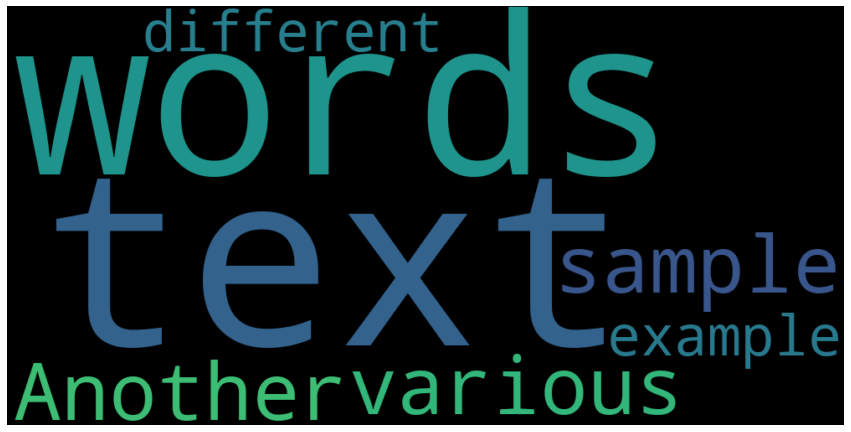

In [21]:
# Install necessary packages directly within the Jupyter notebook
!pip install wordcloud
!pip install matplotlib

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame creation (replace this with your actual data if needed)
data = {'text': ['This is a sample text with various words', 'Another example of text with different words']}
df = pd.DataFrame(data)

# Generate words list excluding stopwords
words = []
for message in df['text']:
    words.extend([word for word in message.split() if word.lower() not in STOPWORDS])

# Generate and display the word cloud
wordcloud = WordCloud(width=1000, height=500, stopwords=STOPWORDS).generate(" ".join(words))
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


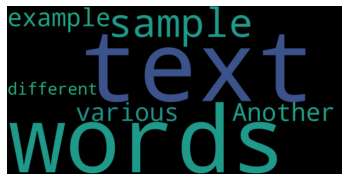

In [22]:
# word cloud
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import matplotlib.pyplot as plt
words = []
for message in df['text']:
    words.extend([word for word in message.split() if word not in STOPWORDS])

wordcloud = WordCloud(width = 1000, height = 500).generate(" ".join(words))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [23]:
from textblob import TextBlob

text_1 = "The movie was so awesome."
text_2 = "The food here tastes terrible."

#Determining the Polarity
p_1 = TextBlob(text_1).sentiment.polarity
p_2 = TextBlob(text_2).sentiment.polarity

#Determining the Subjectivity
s_1 = TextBlob(text_1).sentiment.subjectivity
s_2 = TextBlob(text_2).sentiment.subjectivity

print("Polarity of Text 1 is", p_1)
print("Polarity of Text 2 is", p_2)
print("Subjectivity of Text 1 is", s_1)
print("Subjectivity of Text 2 is", s_2)

Polarity of Text 1 is 1.0
Polarity of Text 2 is -1.0
Subjectivity of Text 1 is 1.0
Subjectivity of Text 2 is 1.0


In [24]:
!pip install vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/126.0 kB ? eta -:--:--

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.5 MB/s eta 0:00:00


In [25]:

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sentiment = SentimentIntensityAnalyzer()
text_1 = "The book was a perfect balance between wrtiting style and plot."
text_2 =  "The pizza tastes terrible."
sent_1 = sentiment.polarity_scores(text_1)
sent_2 = sentiment.polarity_scores(text_2)
print("Sentiment of text 1:", sent_1)
print("Sentiment of text 2:", sent_2)

Sentiment of text 1: {'neg': 0.0, 'neu': 0.73, 'pos': 0.27, 'compound': 0.5719}
Sentiment of text 2: {'neg': 0.508, 'neu': 0.492, 'pos': 0.0, 'compound': -0.4767}
